In [3]:
experiment_name = "combined"   
num_nodes = 241
normalize_metrics = {
    "accuracy": None,
    "avg rank of source": lambda x: x / num_nodes,
    "source in top 20": None,
}

Loading results from latest file: /sc/home/johanna.dahlkemper/source_detection_in_grns/reports/01_pathway_experiments/combined/combined_kfold_aggregated_0130_2018.json
Loaded results:
{'pdgrapher': {'num_folds': 5, 'accuracy_mean': 0.0422, 'accuracy_std': 0.0043, 'accuracy_min': 0.035, 'accuracy_max': 0.047, 'avg rank of source_mean': 351.3412, 'avg rank of source_std': 108.5762, 'avg rank of source_min': 293.896, 'avg rank of source_max': 568.447, 'avg norm rank of source_mean': 0.1296, 'avg norm rank of source_std': 0.0402, 'avg norm rank of source_min': 0.108, 'avg norm rank of source_max': 0.21, 'avg prediction for source_mean': 0.8062, 'avg prediction for source_std': 0.1277, 'avg prediction for source_min': 0.551, 'avg prediction for source_max': 0.878, 'avg prediction over all nodes_mean': -0.4976, 'avg prediction over all nodes_std': 0.0008, 'avg prediction over all nodes_min': -0.499, 'avg prediction over all nodes_max': -0.497, 'min prediction over all nodes_mean': -3.7932, '

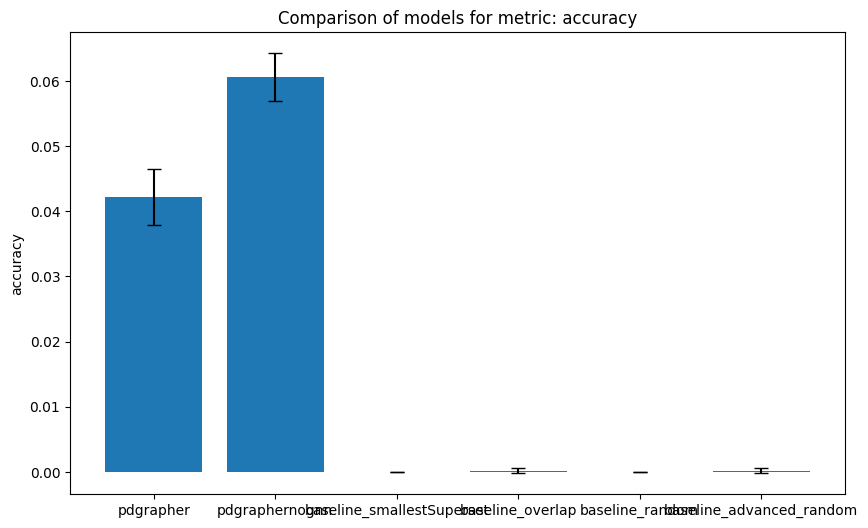

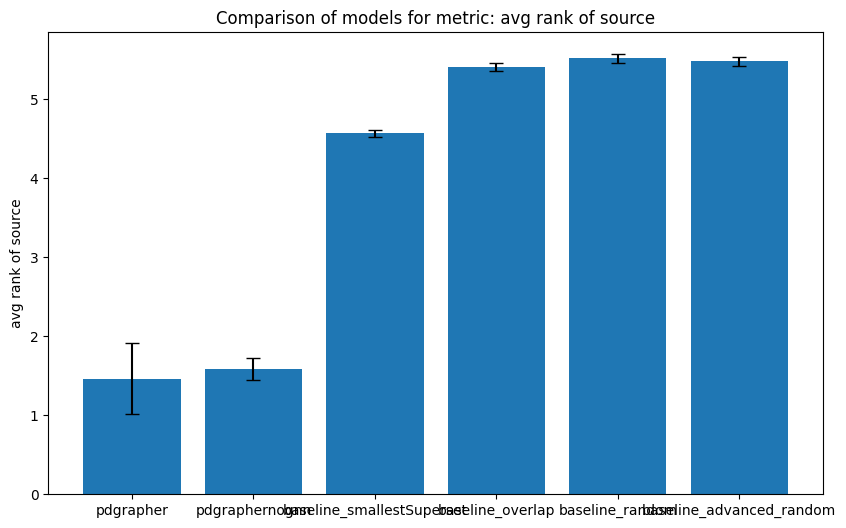

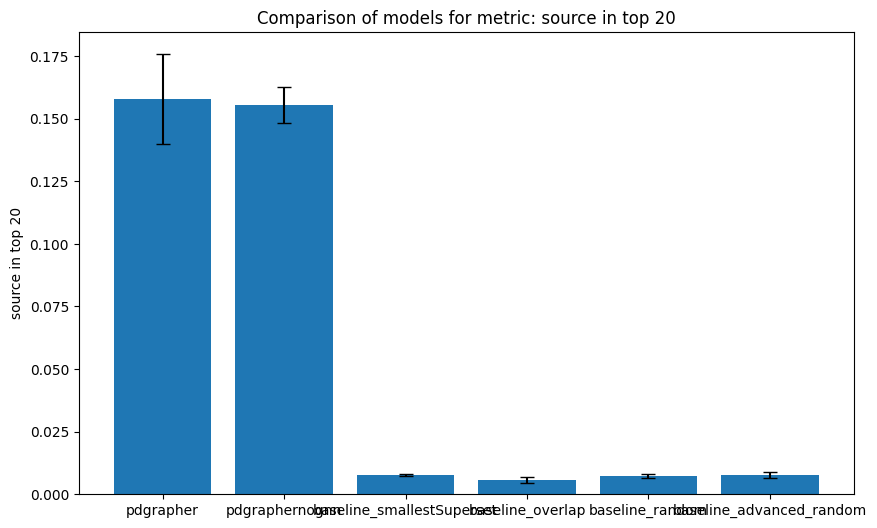

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

current_dir = Path().resolve()
report_base = current_dir / experiment_name
aggregate_files = list(report_base.glob(f"{experiment_name}_kfold_aggregated_*.json"))

assert len(aggregate_files) > 0, f"No aggregated files found in {report_base}"

# Get the latest file by modification time
latest_file = max(aggregate_files, key=lambda p: p.stat().st_mtime)
print(f"Loading results from latest file: {latest_file}")

with open(latest_file, 'r') as f:
    data = json.load(f)

assert 'results' in data, f"'results' key not found in {latest_file}"
final_results = data['results']

print("Loaded results:")
print(final_results)

# create bar plots for each metric
for metric in normalize_metrics.keys():
    means = []
    stds = []
    labels = []
    
    for model, metrics_dict in final_results.items():
        mean_key = metric + "_mean"
        std_key = metric + "_std"
        
        if mean_key in metrics_dict:
            mean_value = metrics_dict[mean_key]
            std_value = metrics_dict[std_key]
            
            if metric in normalize_metrics and normalize_metrics[metric] is not None:
                mean_value = normalize_metrics[metric](mean_value)
                std_value = normalize_metrics[metric](std_value)
            
            means.append(mean_value)
            stds.append(std_value)
            labels.append(model)
    
    if len(means) > 0:
        x = np.arange(len(labels))
        plt.figure(figsize=(10, 6))
        plt.bar(x, means, yerr=stds, capsize=5)
        plt.xticks(x, labels)
        plt.ylabel(metric)
        plt.title(f"Comparison of models for metric: {metric}")
        plt.show()
